<a href="https://colab.research.google.com/github/umang0015/Ai-DataScience/blob/main/student_performance23July.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import matplotlib.pyplot as plt


In [37]:
df = pd.read_csv('/content/drive/MyDrive/Student_Performance - Student_Performance.csv')
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23
9996,7,64,Yes,8,5,58
9997,6,83,Yes,8,5,74
9998,9,97,Yes,7,0,95


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


In [40]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [41]:
# preparing data as input ant output
X = df.iloc[: , :-1].values
y = df.iloc[: , -1].values
print(X.shape, y.shape)

(10000, 5) (10000,)


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder' , OneHotEncoder(sparse_output=False),[2])] , remainder='passthrough')
X = ct.fit_transform(X)

In [43]:
print(X.shape)

(10000, 6)


In [44]:
X

array([[0.0, 1.0, 7, 99, 9, 1],
       [1.0, 0.0, 4, 82, 4, 2],
       [0.0, 1.0, 8, 51, 7, 2],
       ...,
       [0.0, 1.0, 6, 83, 8, 5],
       [0.0, 1.0, 9, 97, 7, 0],
       [1.0, 0.0, 7, 74, 8, 1]], dtype=object)

In [45]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train ,y_test = train_test_split(X, y , test_size=0.2 ,random_state=0)

In [46]:
print(X_train.shape , X_test.shape)
print(y_train.shape , y_test.shape)

(8000, 6) (2000, 6)
(8000,) (2000,)


In [47]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train , y_train)

LinearRegression()

In [48]:
# predicting the test set results
y_pred = regressor.predict(X_test)
y_pred

array([50.45128503, 53.09379171, 78.24502652, ..., 64.56863194,
       25.89718776, 18.82598463])

In [49]:
print(regressor.predict([[0.0, 1.0, 7, 99, 9, 1]]))

[91.90053241]


In [50]:
# Getting the final linear regression equation with the values of the coefficients

In [51]:
print(regressor.coef_)
print(regressor.intercept_)

[-0.33265173  0.33265173  2.85191442  1.01886667  0.47682996  0.18776637]
-33.742556490415765


In [52]:
print('score: {}'.format(regressor.score(X_test , y_test)))

score: 0.9880686410711422


In [53]:
# now we use the style of matplotlib
plt.style.use('fivethirtyeight')


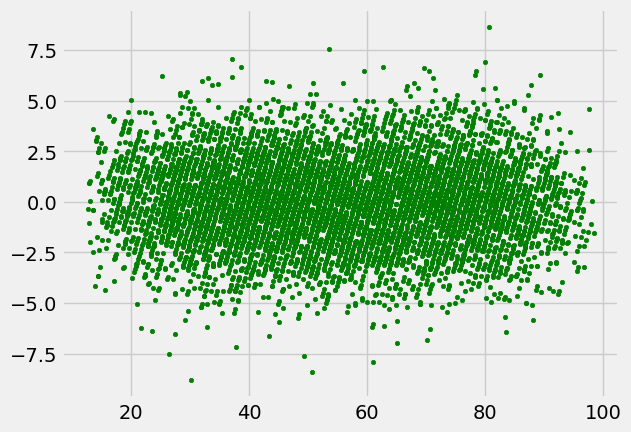

In [54]:
plt.scatter(regressor.predict(X_train) , regressor.predict(X_train) - y_train , color='green' , s=10 , label='Train data')

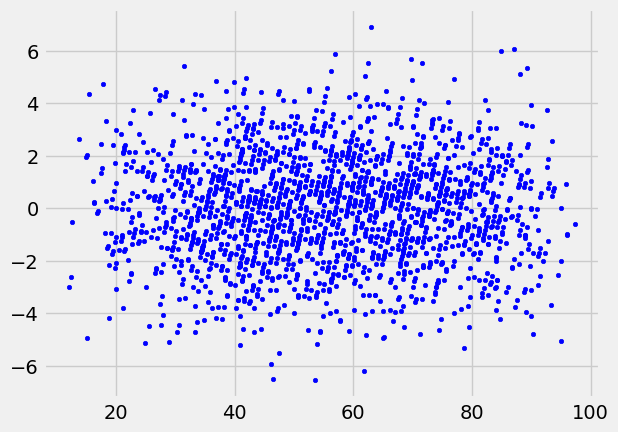

In [55]:
plt.scatter(regressor.predict(X_test) , regressor.predict(X_test) - y_test , color='blue' , s=10 , label='Train data')

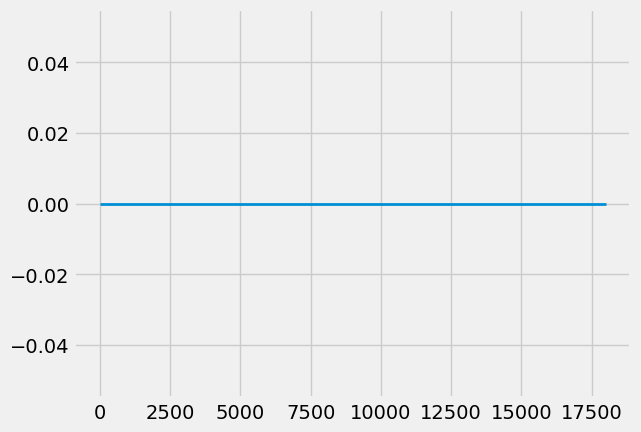

In [56]:
plt.hlines(y=0 , xmin=0 , xmax = 18000,linewidth=2)

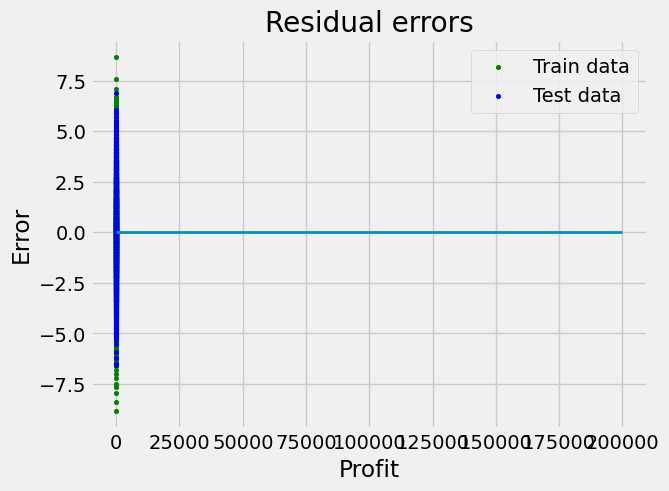

In [57]:
plt.style.use('fivethirtyeight')
plt.scatter(regressor.predict(X_train) , regressor.predict(X_train) - y_train ,color='green' , s=10,label='Train data')
plt.scatter(regressor.predict(X_test) , regressor.predict(X_test) - y_test, color='blue' , s=10,label='Test data')

plt.hlines(y=0 , xmin=0 ,xmax=200000 , linewidth=2)
plt.legend(loc='upper right')
plt.title('Residual errors')
plt.xlabel('Profit')
plt.ylabel('Error')
plt.show()

In [58]:
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))

0.9880686410711422


In [60]:
# MAE ,RMSE
from sklearn.metrics import mean_absolute_error
print(mean_absolute_error(y_test ,y_pred))

1.6229708329710857


In [64]:
import numpy as np
from sklearn.metrics import root_mean_squared_error
print(root_mean_squared_error(y_test ,y_pred))

2.0262302968408665
